# Analyse d'un run — propagation des vagues de cAMP

Diagnostic de la **synchronisation** et de la **propagation** des vagues.

Trois sources de données :
- `field_diagnostics.csv` — scalaires globaux par instant (tableau de bord)
- `simulation_data.csv` — état de chaque cellule (`b`, `r_T`, position) par frame
- `fields/camp_*.npy` + `field_times.csv` — champ cAMP spatial complet

La question centrale : **a-t-on un front qui se déplace** (vague) ou des îlots qui clignotent (pas de propagation) ? Ça se mesure surtout sur les champs `.npy` (kymographe + vitesse de front).

In [12]:
import os, glob, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# >>> SEUL CHEMIN A MODIFIER <<<
RUN_DIR = "/Users/souchaud/Desktop/simulations/simu_2026-06-05_16-15-39"

GRID_RESOLUTION = 2.0   # µm/case — doit correspondre au complet.py du run
K_h = 3e-8              # seuil d'activation (M) = 30 nM, pour les isolignes

diag_path   = os.path.join(RUN_DIR, "field_diagnostics.csv")
cells_path  = os.path.join(RUN_DIR, "simulation_data.csv")
fields_dir  = os.path.join(RUN_DIR, "fields")
ftimes_path = os.path.join(RUN_DIR, "field_times.csv")

print("Run :", os.path.basename(RUN_DIR))
for label, p in [("diagnostics", diag_path), ("cells", cells_path),
                 ("field_times", ftimes_path), ("fields/", fields_dir)]:
    sz = ""
    if os.path.exists(p) and not os.path.isdir(p):
        sz = f"  ({os.path.getsize(p)/1e9:.2f} Go)"
    print(f"  {label:14s}: {'OK' if os.path.exists(p) else 'ABSENT'}  {p}{sz}")

Run : simu_2026-06-05_16-15-39
  diagnostics   : OK  /Users/souchaud/Desktop/simulations/simu_2026-06-05_16-15-39/field_diagnostics.csv  (0.00 Go)
  cells         : OK  /Users/souchaud/Desktop/simulations/simu_2026-06-05_16-15-39/simulation_data.csv  (1.35 Go)
  field_times   : OK  /Users/souchaud/Desktop/simulations/simu_2026-06-05_16-15-39/field_times.csv  (0.00 Go)
  fields/       : OK  /Users/souchaud/Desktop/simulations/simu_2026-06-05_16-15-39/fields


## 1. Tableau de bord global (`field_diagnostics.csv`)

`r_T_mean` qui se verrouille bas = récepteurs bloqués réfractaires = pas de re-excitation. `camp_max` avec des pics francs et récurrents = vagues ; un bruit dense sans pics = régime mou.

600 points, t = 0.0 -> 599.0 min


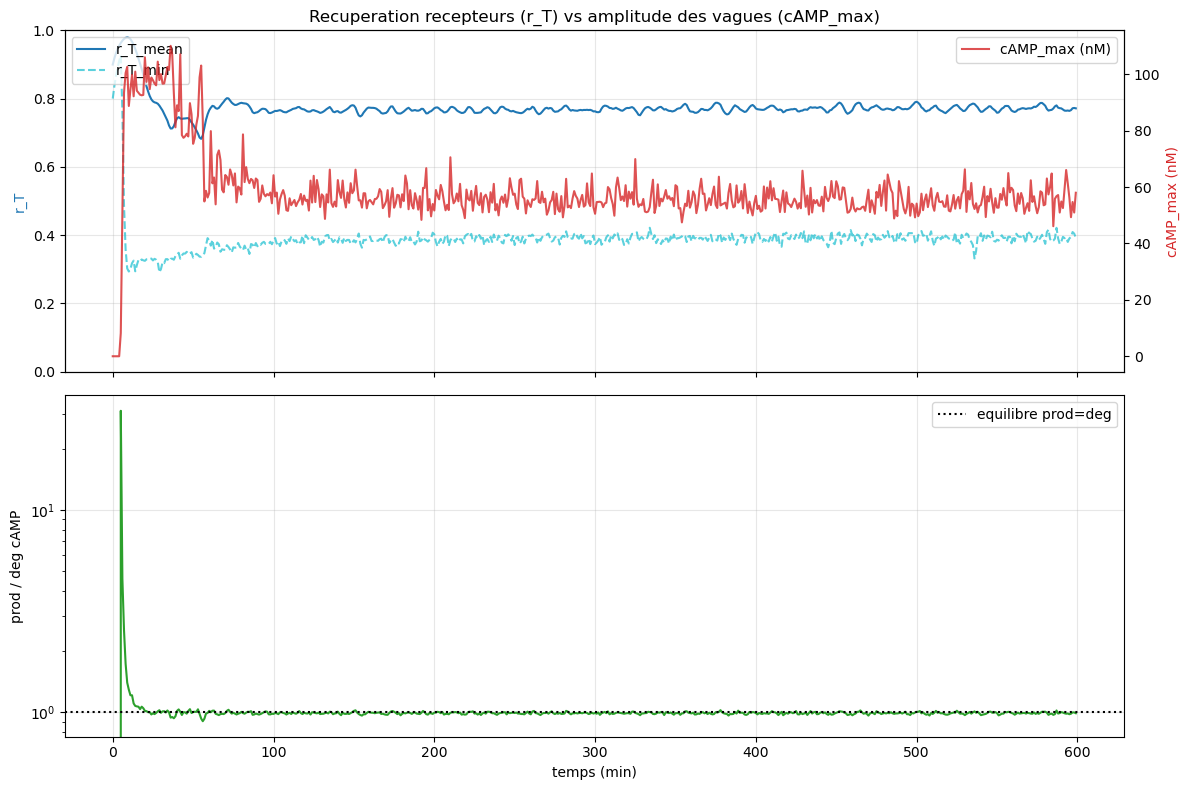

r_T_mean : debut 0.93 -> regime etabli 0.77 (oscillation std=0.0073)
cAMP_max regime etabli : moyenne 55.5 nM, std 3.7 nM  (std/moy=0.07)
  -> std/moy faible = pics ecrases (regime mou) ; eleve = bouffees distinctes (vagues)


In [13]:
diag = pd.read_csv(diag_path)
print(f"{len(diag)} points, t = {diag['time'].min():.1f} -> {diag['time'].max():.1f} min")

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# (a) recuperation des recepteurs + amplitude cAMP
ax1 = axes[0]
ax1.plot(diag['time'], diag['r_T_mean'], color='tab:blue', label='r_T_mean')
if 'r_T_min' in diag:
    ax1.plot(diag['time'], diag['r_T_min'], color='tab:cyan', ls='--', alpha=0.7, label='r_T_min')
ax1.set_ylabel('r_T', color='tab:blue'); ax1.set_ylim(0, 1)
ax1.legend(loc='upper left'); ax1.grid(alpha=0.3)
axb = ax1.twinx()
axb.plot(diag['time'], diag['camp_max'] * 1e9, color='tab:red', alpha=0.8, label='cAMP_max (nM)')
axb.set_ylabel('cAMP_max (nM)', color='tab:red'); axb.legend(loc='upper right')
ax1.set_title("Recuperation recepteurs (r_T) vs amplitude des vagues (cAMP_max)")

# (b) bilan production / degradation — une vague survit si le ratio repasse > 1 par bouffees
ax2 = axes[1]
if 'camp_prod_deg_ratio' in diag:
    ax2.plot(diag['time'], diag['camp_prod_deg_ratio'], color='tab:green')
    ax2.axhline(1.0, color='k', ls=':', label='equilibre prod=deg')
    ax2.set_ylabel('prod / deg cAMP'); ax2.set_yscale('log'); ax2.legend()
ax2.set_xlabel('temps (min)'); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Resume chiffre
post = diag[diag['time'] > diag['time'].max() * 0.4]
print(f"r_T_mean : debut {diag['r_T_mean'].iloc[2]:.2f} -> regime etabli {post['r_T_mean'].mean():.2f} "
      f"(oscillation std={post['r_T_mean'].std():.4f})")
print(f"cAMP_max regime etabli : moyenne {post['camp_max'].mean()*1e9:.1f} nM, "
      f"std {post['camp_max'].std()*1e9:.1f} nM  (std/moy={post['camp_max'].std()/post['camp_max'].mean():.2f})")
print("  -> std/moy faible = pics ecrases (regime mou) ; eleve = bouffees distinctes (vagues)")

## 2. Champs spatiaux — chargement des `.npy`

On charge la pile de grilles cAMP dans l'ordre temporel (via `field_times.csv`). C'est la donnée qui permet de *voir* la propagation, impossible à reconstruire depuis les scalaires.

In [14]:
def load_camp_stack(fields_dir, ftimes_path, max_frames=None):
    """Charge les grilles cAMP dans l'ordre temporel.
    Retourne (stack [T,Nx,Ny], times [T]). Robuste a un arret manuel de la simu
    (un .npy a moitie ecrit en fin de fichier est ignore)."""
    files = glob.glob(os.path.join(fields_dir, "camp_*.npy"))
    if not files:
        raise FileNotFoundError(f"Aucun camp_*.npy dans {fields_dir}")
    # tri par numero d'iteration extrait du nom
    def it_of(f): return int(re.search(r"camp_(\d+)\.npy", os.path.basename(f)).group(1))
    files = sorted(files, key=it_of)
    iters = [it_of(f) for f in files]

    # mapping iteration -> time
    it2t = {}
    if os.path.exists(ftimes_path):
        ft = pd.read_csv(ftimes_path)
        it2t = dict(zip(ft['iteration'], ft['time']))

    if max_frames and len(files) > max_frames:
        step = len(files) // max_frames
        files, iters = files[::step], iters[::step]

    grids, times = [], []
    for f, it in zip(files, iters):
        try:
            g = np.load(f)
        except (ValueError, EOFError, OSError):
            print(f"  (ignore {os.path.basename(f)} — fichier incomplet)")
            continue
        grids.append(g)
        times.append(it2t.get(it, it * 0.001))  # fallback DELTA_T=0.001
    stack = np.stack(grids)
    return stack, np.array(times)

camp_stack, camp_times = load_camp_stack(fields_dir, ftimes_path)
print(f"Pile cAMP : {camp_stack.shape}  (T={camp_stack.shape[0]} frames, "
      f"grille {camp_stack.shape[1]}x{camp_stack.shape[2]})")
print(f"Temps : {camp_times.min():.2f} -> {camp_times.max():.2f} min, "
      f"pas median {np.median(np.diff(camp_times)):.3f} min")
print(f"cAMP global : max {camp_stack.max()*1e9:.1f} nM")

Pile cAMP : (1200, 500, 500)  (T=1200 frames, grille 500x500)
Temps : 0.00 -> 599.50 min, pas median 0.500 min
cAMP global : max 110.1 nM


## 3. Kymographe — l'outil décisif pour la propagation

Coupe spatiale (1D) du champ cAMP, empilée dans le temps. Lecture des motifs :
- **bandes diagonales** → fronts qui se propagent ; la pente donne la **vitesse** (µm/min)
- **bandes verticales** → tout le domaine s'allume/s'éteint ensemble = oscillation globale, **pas de propagation**
- **taches éparses sans structure** → îlots désynchronisés = ce que tu décrivais

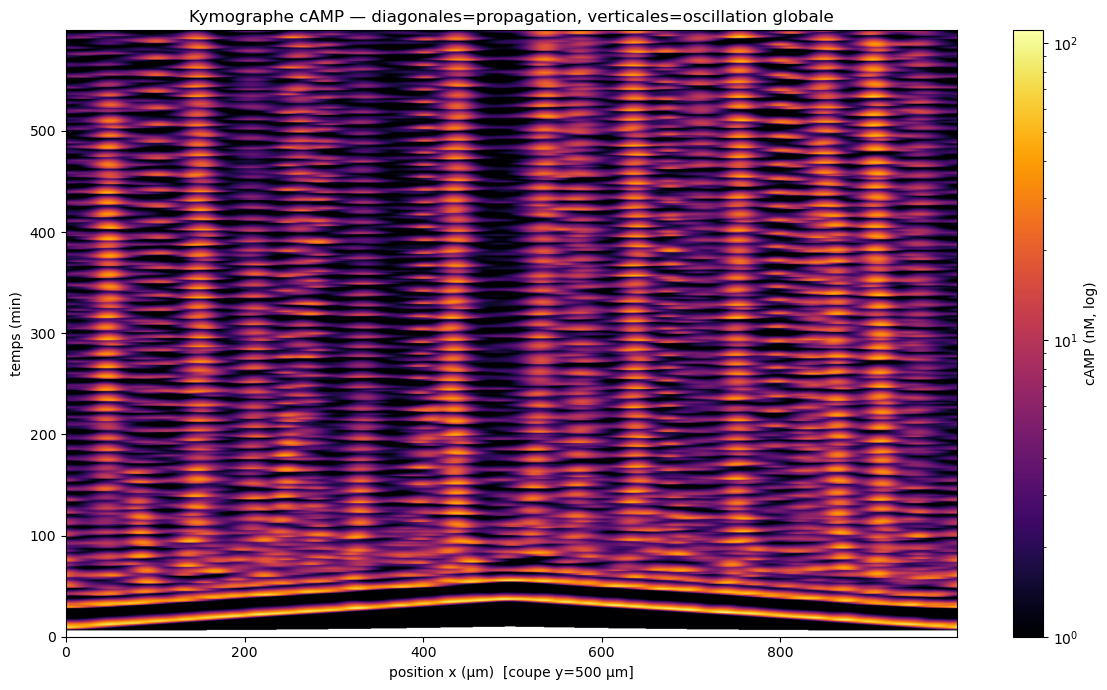

In [15]:
from matplotlib.colors import LogNorm

Nx, Ny = camp_stack.shape[1], camp_stack.shape[2]
row = Nx // 2  # coupe horizontale au milieu (axe 0 = x)

# kymographe : lignes = temps, colonnes = position x le long de la coupe
kymo = camp_stack[:, row, :]            # [T, Ny]
x_um = np.arange(Ny) * GRID_RESOLUTION

fig, ax = plt.subplots(figsize=(12, 7))
vmax = max(camp_stack.max(), 1e-9)
im = ax.imshow(kymo * 1e9, aspect='auto', origin='lower', cmap='inferno',
               extent=[x_um[0], x_um[-1], camp_times[0], camp_times[-1]],
               norm=LogNorm(vmin=1.0, vmax=vmax * 1e9))
ax.set_xlabel(f'position x (µm)  [coupe y={row*GRID_RESOLUTION:.0f} µm]')
ax.set_ylabel('temps (min)')
ax.set_title('Kymographe cAMP — diagonales=propagation, verticales=oscillation globale')
plt.colorbar(im, ax=ax, label='cAMP (nM, log)')
plt.tight_layout(); plt.show()

## 4. Snapshots 2D — forme spatiale des vagues

Une vraie propagation donne des **anneaux concentriques** ou des **spirales** autour des sources. Des taches statiques qui clignotent sur place = pas de propagation.

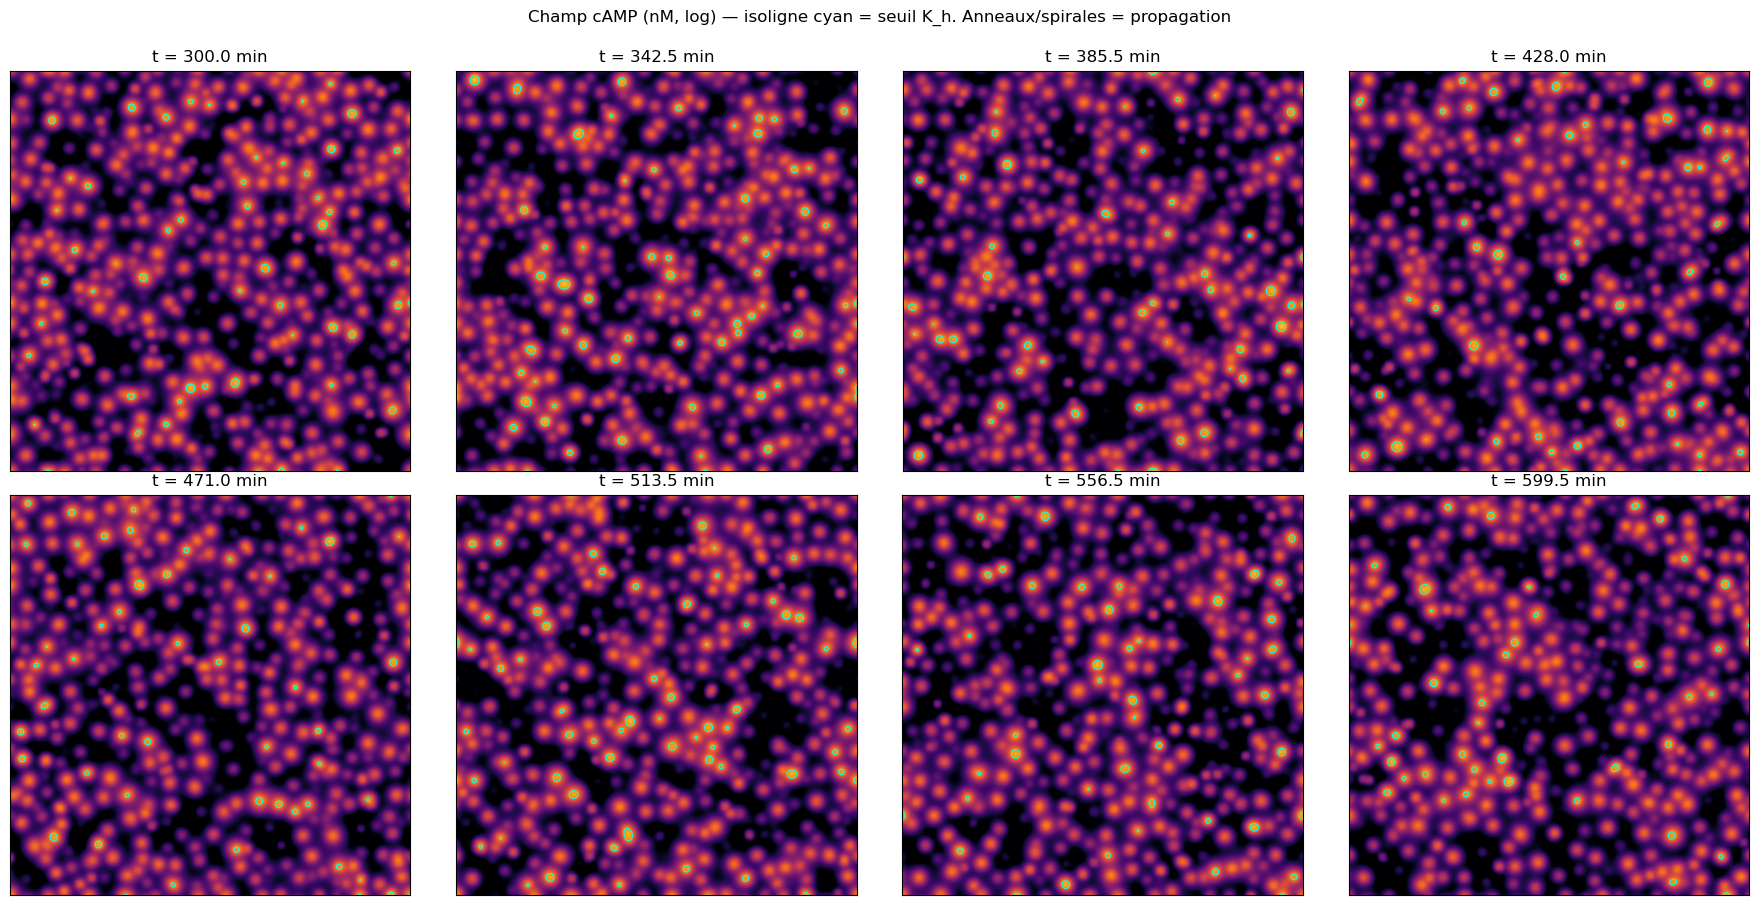

In [16]:
# 8 snapshots regulierement espaces dans la 2e moitie (regime etabli)
T = camp_stack.shape[0]
idxs = np.linspace(T // 2, T - 1, 8).astype(int)
extent = [0, Ny * GRID_RESOLUTION, 0, Nx * GRID_RESOLUTION]
vmax = max(camp_stack.max() * 1e9, 1.0)

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for ax, k in zip(axes.flat, idxs):
    im = ax.imshow(camp_stack[k].T * 1e9, origin='lower', extent=extent,
                   cmap='inferno', norm=LogNorm(vmin=1.0, vmax=vmax))
    ax.contour(camp_stack[k].T * 1e9, levels=[K_h * 1e9], extent=extent,
               colors='cyan', linewidths=0.8)  # isoligne du seuil d'activation
    ax.set_title(f't = {camp_times[k]:.1f} min')
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle('Champ cAMP (nM, log) — isoligne cyan = seuil K_h. Anneaux/spirales = propagation', y=1.0)
plt.tight_layout(); plt.show()

## 5. Synchronisation : oscillation globale ou onde progressive ?

On découpe le domaine en régions et on regarde la **série temporelle moyenne** de chacune. La question : sont-elles en phase (oscillation globale) ou décalées d'une région à l'autre (onde qui voyage) ?

- séries quasi superposées → **oscillation globale**, tout le monde bat ensemble
- séries décalées dans le temps de proche en proche → **onde progressive** (ce qu'on veut)
- séries chacune dans son coin, incohérentes → **désynchronisation** (le problème actuel)

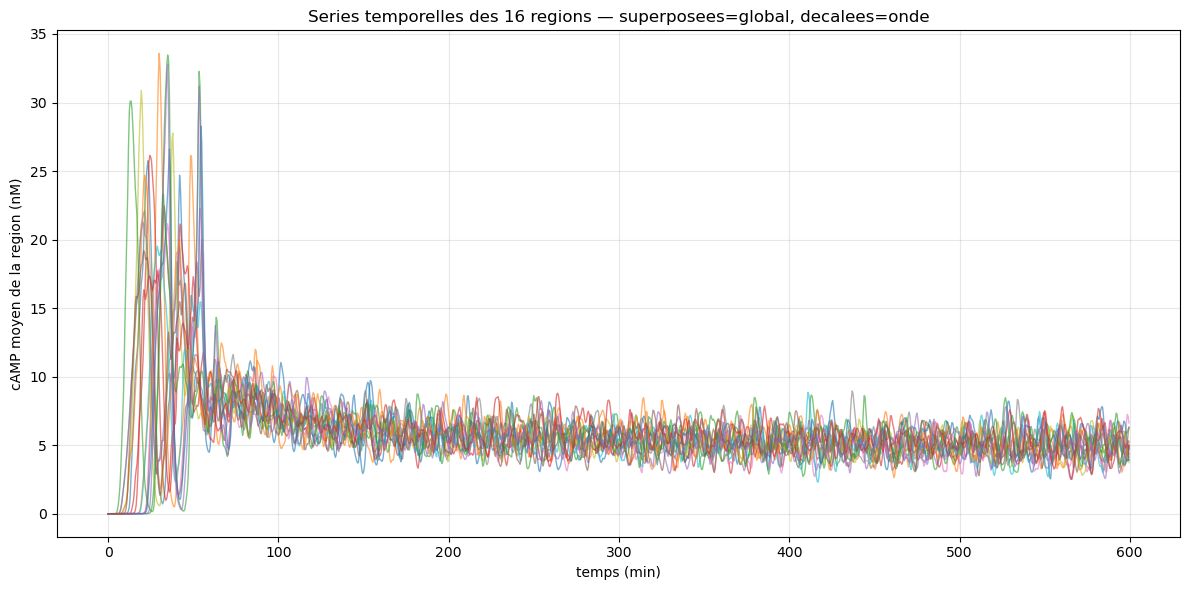

Decalage temporel de chaque region vs centre (min) — non-nul croissant avec distance = onde :
  +12.00  +5.00  +0.50  +9.00 
  +13.00  +0.50  +0.50 +13.00 
  +14.50  +3.00  +0.00 +12.00 
  +19.50  +6.50  +1.00 +12.00 

-> tous ~0.00 : oscillation globale (pas de propagation).
-> gradient regulier de decalages : onde qui traverse le domaine.


In [17]:
# Decoupe en grille n_reg x n_reg de regions, serie temporelle moyenne de cAMP par region
n_reg = 4
xs = np.linspace(0, Nx, n_reg + 1, dtype=int)
ys = np.linspace(0, Ny, n_reg + 1, dtype=int)

series = {}
for i in range(n_reg):
    for j in range(n_reg):
        block = camp_stack[:, xs[i]:xs[i+1], ys[j]:ys[j+1]]
        series[(i, j)] = block.mean(axis=(1, 2))  # [T]

fig, ax = plt.subplots(figsize=(12, 6))
for (i, j), s in series.items():
    ax.plot(camp_times, s * 1e9, alpha=0.6, lw=1)
ax.set_xlabel('temps (min)'); ax.set_ylabel('cAMP moyen de la region (nM)')
ax.set_title(f'Series temporelles des {n_reg*n_reg} regions — superposees=global, decalees=onde')
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

# Indice quantitatif : decalage de phase region-a-region via correlation croisee
center = series[(n_reg//2, n_reg//2)]
center = center - center.mean()
def best_lag(a, b, dt):
    a = a - a.mean(); b = b - b.mean()
    if a.std() < 1e-30 or b.std() < 1e-30: return 0.0
    corr = np.correlate(a, b, mode='full')
    lag = (np.argmax(corr) - (len(a) - 1))
    return lag * dt

dt = float(np.median(np.diff(camp_times)))
print("Decalage temporel de chaque region vs centre (min) — non-nul croissant avec distance = onde :")
for i in range(n_reg):
    line = ""
    for j in range(n_reg):
        s = series[(i, j)] - series[(i, j)].mean()
        line += f"{best_lag(center, s, dt):+6.2f} "
    print("  " + line)
print("\n-> tous ~0.00 : oscillation globale (pas de propagation).")
print("-> gradient regulier de decalages : onde qui traverse le domaine.")

## 6. Vitesses des cellules

Vitesse instantanée par cellule via `diff(position)/diff(time)` avec correction des conditions périodiques. On compare à la consigne `velocity_magnitude_popN` lue dans les paramètres du run.

- v mesurée ≈ consigne → cellules libres de se déplacer
- v mesurée << consigne → encombrement (la répulsion freine la propulsion dans les agrégats denses)
- une pop qui chute alors qu'une autre tient → la pop chuteuse est embouteillée, l'autre est libre

SPACE_SIZE=1000.0 µm, consignes : {'Population 1': 0.7, 'Population 2': 0.5}
CSV cells : 1.35 Go
  6888000 lignes, RAM ~ 0.55 Go
  4592 cellules, t = [0.0, 599.6] min
  pas entre 2 enregistrements par cellule (median): 0.400 min  (LOG_EVERY_MVT=20 actif)


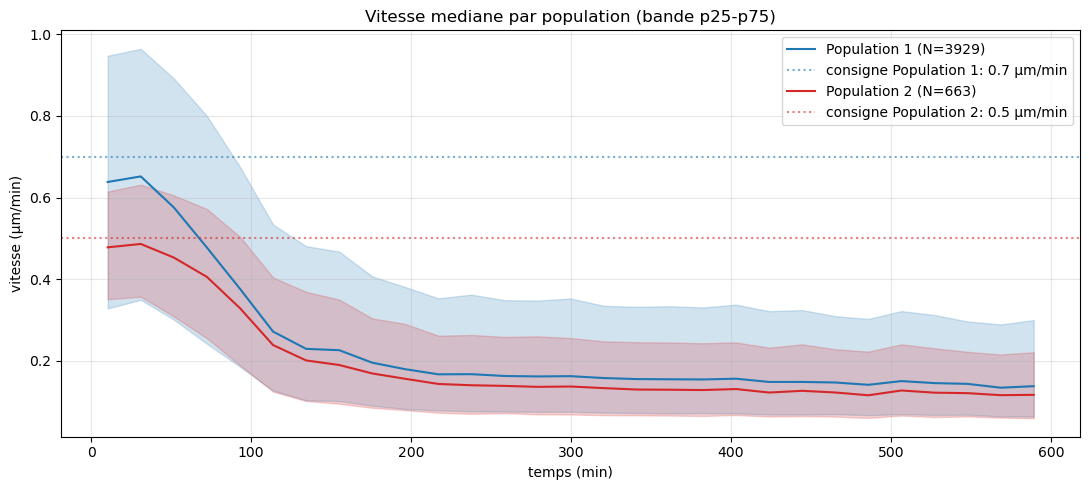


pop                     tranche |  mediane    p25    p75    p95  N_actives(v>0.05)
Population 1   [    0,    50] |    0.642  0.338  0.953  1.387  0.94
Population 1   [   50,   150] |    0.350  0.158  0.665  1.243  0.94
Population 1   [  150,   300] |    0.176  0.081  0.376  0.992  0.86
Population 1   [  300,   500] |    0.152  0.071  0.327  0.905  0.84
Population 1   [  500,   600] |    0.142  0.067  0.303  0.864  0.82
Population 1   [    0,   600] |    0.198  0.085  0.456  1.102  0.86
Population 2   [    0,    50] |    0.482  0.352  0.622  0.821  0.99
Population 2   [   50,   150] |    0.307  0.159  0.493  0.799  0.95
Population 2   [  150,   300] |    0.150  0.076  0.280  0.608  0.86
Population 2   [  300,   500] |    0.127  0.065  0.240  0.550  0.82
Population 2   [  500,   600] |    0.121  0.063  0.226  0.523  0.81
Population 2   [    0,   600] |    0.170  0.081  0.342  0.695  0.87


In [18]:
# --- Chargement robuste : dtypes optimises + bascule chunked si gros CSV ---
SPACE_SIZE_HINT  = 1000.0
MAX_RAM_GB       = 3.0    # bascule en mode chunked si le CSV depasse
SUBSAMPLE_IF_BIG = 10     # si chunked : ne garder qu'1 frame sur N

# Consignes lues dans simulation_parameters.txt
consignes = {}
params_path = os.path.join(RUN_DIR, "simulation_parameters.txt")
if os.path.exists(params_path):
    for line in open(params_path):
        for k in ("velocity_magnitude_pop1", "velocity_magnitude_pop2", "SPACE_SIZE"):
            if line.strip().startswith(k + " "):
                consignes[k] = float(line.split("=")[1].strip())
L = consignes.get("SPACE_SIZE", SPACE_SIZE_HINT)
v_consigne = {"Population 1": consignes.get("velocity_magnitude_pop1", np.nan),
              "Population 2": consignes.get("velocity_magnitude_pop2", np.nan)}
print(f"SPACE_SIZE={L} µm, consignes : {v_consigne}")

# dtypes optimises (divisent la RAM par ~3 vs auto-detection pandas)
DTYPE_MAP = {
    'frame': 'int64', 'time': 'float32', 'cell_id': 'int32',
    'pop_tag': 'category',
    'x': 'float32', 'y': 'float32', 'dir_x': 'float32', 'dir_y': 'float32',
    'b': 'float32', 'r_T': 'float32',
    'is_pioneer': 'bool', 'pulse_active': 'bool', 'relay_activated': 'bool',
    'A_pioneer': 'float32', 'A_relay': 'float32',
}
# garder uniquement les colonnes effectivement presentes
cols_avail = pd.read_csv(cells_path, nrows=0).columns.tolist()
dtype_use = {k: v for k, v in DTYPE_MAP.items() if k in cols_avail}

csv_size_gb = os.path.getsize(cells_path) / 1e9
print(f"CSV cells : {csv_size_gb:.2f} Go")
if csv_size_gb > MAX_RAM_GB:
    print(f"  > {MAX_RAM_GB} Go : lecture chunked, sous-echantillonnage 1 frame sur {SUBSAMPLE_IF_BIG}")
    chunks = []
    for ch in pd.read_csv(cells_path, dtype=dtype_use, chunksize=2_000_000):
        chunks.append(ch[ch['frame'] % SUBSAMPLE_IF_BIG == 0])
    cells_df = pd.concat(chunks, ignore_index=True)
else:
    cells_df = pd.read_csv(cells_path, dtype=dtype_use)

cells_df = cells_df.sort_values(['cell_id', 'time']).reset_index(drop=True)
cells_df['dx'] = (cells_df.groupby('cell_id').x.diff() + L/2) % L - L/2
cells_df['dy'] = (cells_df.groupby('cell_id').y.diff() + L/2) % L - L/2
cells_df['dt'] = cells_df.groupby('cell_id').time.diff()
cells_df['v']  = np.sqrt(cells_df.dx**2 + cells_df.dy**2) / cells_df.dt
m = cells_df.dt.notna() & (cells_df.dt > 0)

dt_med = float(cells_df['dt'].dropna().median())
print(f"  {len(cells_df)} lignes, RAM ~ {cells_df.memory_usage(deep=True).sum()/1e9:.2f} Go")
print(f"  {cells_df.cell_id.nunique()} cellules, t = [{cells_df.time.min():.1f}, {cells_df.time.max():.1f}] min")
print(f"  pas entre 2 enregistrements par cellule (median): {dt_med:.3f} min  "
      f"({'LOG_EVERY_MVT=20 actif' if dt_med > 0.1 else 'log dense, LOG_EVERY_MVT=1'})")

# Plot mediane (+ p25-p75) par pop dans le temps
fig, ax = plt.subplots(figsize=(11, 5))
colors = {"Population 1": "tab:blue", "Population 2": "tab:red"}
t_bins = np.linspace(cells_df.time.min(), cells_df.time.max(), 30)
t_mid = 0.5*(t_bins[1:]+t_bins[:-1])
for pop, g in cells_df[m].groupby('pop_tag', observed=True):
    med, p25, p75 = [], [], []
    for t0, t1 in zip(t_bins[:-1], t_bins[1:]):
        s = g[(g.time >= t0) & (g.time < t1)].v
        med.append(s.median() if len(s) else np.nan)
        p25.append(s.quantile(.25) if len(s) else np.nan)
        p75.append(s.quantile(.75) if len(s) else np.nan)
    c = colors.get(pop, 'gray')
    ax.plot(t_mid, med, color=c, label=f"{pop} (N={g.cell_id.nunique()})")
    ax.fill_between(t_mid, p25, p75, color=c, alpha=0.2)
    if pop in v_consigne and not np.isnan(v_consigne[pop]):
        ax.axhline(v_consigne[pop], color=c, ls=':', alpha=0.6,
                   label=f"consigne {pop}: {v_consigne[pop]} µm/min")
ax.set_xlabel('temps (min)'); ax.set_ylabel('vitesse (µm/min)')
ax.set_title('Vitesse mediane par population (bande p25-p75)')
ax.grid(alpha=0.3); ax.legend(); plt.tight_layout(); plt.show()

# Tableau par tranches adaptees a la duree du run
TMAX = cells_df.time.max()
tranches = [(0, 50), (50, 150), (150, 300), (300, 500), (500, TMAX), (0, TMAX)]
print(f"\n{'pop':14s} {'tranche':>16s} | {'mediane':>8s} {'p25':>6s} {'p75':>6s} {'p95':>6s}  N_actives(v>0.05)")
for pop, g in cells_df[m].groupby('pop_tag', observed=True):
    for t0, t1 in tranches:
        s = g[(g.time >= t0) & (g.time < t1)].v
        if not len(s): continue
        print(f"{pop:14s} [{t0:5.0f}, {t1:5.0f}] | {s.median():8.3f} {s.quantile(.25):6.3f} {s.quantile(.75):6.3f} {s.quantile(.95):6.3f}  {(s>0.05).mean():.2f}")

## 7. Pionnières vs amas — coïncidence spatiale

Pour qu'un amat se *stabilise* (et ne se dissolve pas à la prochaine vague), il doit héberger une source locale de cAMP. Sinon les vagues venant d'ailleurs continuent à tirer les cellules hors de l'amat.

Test : on superpose à plusieurs instants
- toutes les cellules (gris clair),
- les **top-10 amas** détectés par clustering de voisinage (couleurs + croix au centroïde),
- les **pionnières** (croix noires épaisses).

Lecture :
- pionnières **à l'intérieur** des amas, centroïdes proches → couplage source/amat OK
- pionnières **loin** (≫ longueur de diffusion ≈ 32 µm) → amas non auto-entretenus → ils se dissolvent

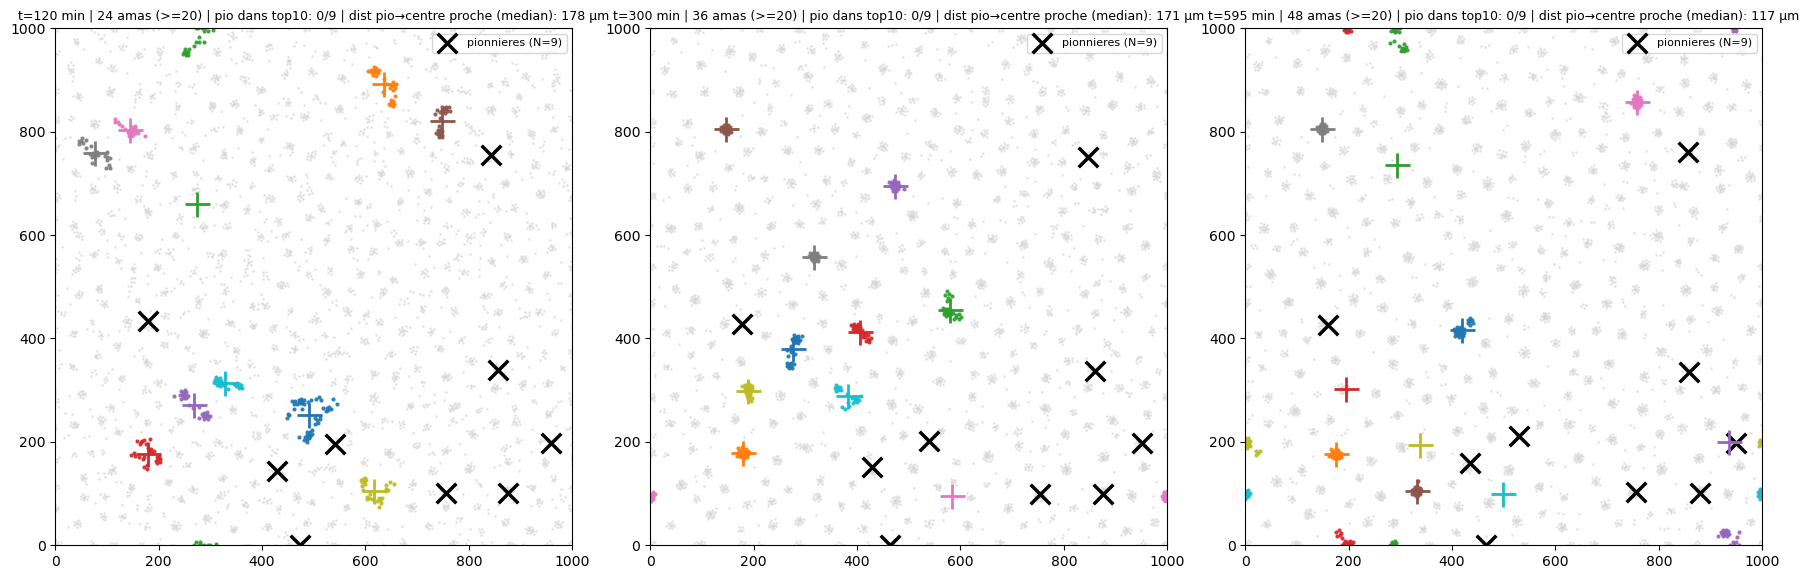


Repere : longueur de diffusion cAMP ≈ √(D/J) ≈ 32 µm
Si la mediane des distances pio→centre est >> 32 µm, les pionnieres et les amas
sont chimiquement deconnectes : les amas n'ont pas de source locale et se dissolvent.


In [19]:
from scipy.spatial import cKDTree

CLUSTER_RADIUS = 16.0   # rayon de connexion entre voisins pour definir un amat (µm)
MIN_AMAT_SIZE  = 20     # taille minimale pour compter comme "vrai" amat
TOP_K          = 10     # nb d'amas affiches en couleur
# Adapte automatiquement aux runs longs : 3 instants etales sur la duree
_TMAX = cells_df['time'].max()
SNAPSHOT_TIMES = [_TMAX * 0.2, _TMAX * 0.5, _TMAX - 5]

def find_amats(pts, L, radius=CLUSTER_RADIUS, min_size=MIN_AMAT_SIZE):
    """Union-find sur paires de cellules proches (PBC). Retourne liste de clusters."""
    tree = cKDTree(pts, boxsize=L)
    pairs = tree.query_pairs(r=radius)
    parent = list(range(len(pts)))
    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x
    for a, b in pairs:
        ra, rb = find(a), find(b)
        if ra != rb: parent[ra] = rb
    comp = {}
    for i in range(len(pts)):
        comp.setdefault(find(i), []).append(i)
    amats = [np.array(idx) for idx in comp.values() if len(idx) >= min_size]
    return sorted(amats, key=len, reverse=True)

# Distance PBC entre deux points (pour distances pionniere -> centroide)
def pbc_dist(p, q, L):
    d = np.abs(p - q); d = np.minimum(d, L - d)
    return np.sqrt((d ** 2).sum())

fig, axes = plt.subplots(1, len(SNAPSHOT_TIMES), figsize=(6 * len(SNAPSHOT_TIMES), 6))
if len(SNAPSHOT_TIMES) == 1: axes = [axes]

for ax, t_tgt in zip(axes, SNAPSHOT_TIMES):
    f = cells_df.iloc[(cells_df.time - t_tgt).abs().argsort().iloc[:1]].frame.iloc[0]
    sub = cells_df[cells_df.frame == f].reset_index(drop=True)
    pts = sub[['x', 'y']].values % L
    pio_mask = sub.is_pioneer.values.astype(bool)
    amats = find_amats(pts, L)

    ax.scatter(pts[:, 0], pts[:, 1], s=1, c='lightgrey', alpha=0.5)
    palette = plt.cm.tab10(np.linspace(0, 1, min(TOP_K, len(amats))))
    centroids = []
    pio_inside_top = 0
    for k, idx in enumerate(amats[:TOP_K]):
        p = pts[idx]
        ax.scatter(p[:, 0], p[:, 1], s=4, c=[palette[k]], alpha=0.85)
        cx, cy = p.mean(0)
        centroids.append((cx, cy))
        ax.plot(cx, cy, '+', color=palette[k], markersize=18, mew=2)
        pio_inside_top += int(pio_mask[idx].sum())

    pio_pos = pts[pio_mask]
    ax.scatter(pio_pos[:, 0], pio_pos[:, 1], s=200, c='black', marker='x',
               linewidths=2.5, label=f'pionnieres (N={pio_mask.sum()})')

    if len(centroids) and len(pio_pos):
        centroids = np.array(centroids)
        d_min = [min(pbc_dist(pp, c, L) for c in centroids) for pp in pio_pos]
        med_d = float(np.median(d_min))
        title = (f't={t_tgt:.0f} min | {len(amats)} amas (>={MIN_AMAT_SIZE}) | '
                 f'pio dans top{TOP_K}: {pio_inside_top}/{pio_mask.sum()} | '
                 f'dist pio→centre proche (median): {med_d:.0f} µm')
    else:
        title = f't={t_tgt:.0f} min | {len(amats)} amas detectes'
    ax.set_title(title, fontsize=9)
    ax.set_xlim(0, L); ax.set_ylim(0, L); ax.set_aspect('equal')
    ax.legend(loc='upper right', fontsize=8)

plt.tight_layout(); plt.show()

print(f"\nRepere : longueur de diffusion cAMP ≈ √(D/J) ≈ 32 µm")
print("Si la mediane des distances pio→centre est >> 32 µm, les pionnieres et les amas")
print("sont chimiquement deconnectes : les amas n'ont pas de source locale et se dissolvent.")

## 8. Tracking arrière des amas — d'où viennent les cellules ?

On repère les **top-K amas à `t_final`**, on note leurs `cell_id`, puis on remonte le temps : à chaque instant antérieur, on colore les mêmes cellules avec **leur couleur de destination**. Les couleurs sont **cohérentes** d'une vignette à l'autre par construction (on suit des IDs, pas une détection re-faite).

Lecture :
- les cellules rouges à `t_early` sont déjà groupées et restent groupées → amat **stable** qui croît
- les cellules rouges à `t_early` sont **éparpillées** → l'amat final s'est *condensé* à partir de cellules dispersées
- les cellules rouges à `t_early` sont groupées **ailleurs** → l'amat a **migré**
- la trajectoire du centroïde (croix `+` reliées par flèches) donne la **vitesse moyenne** de migration de chaque amat

Note : on ne suit *que* les cellules qui finissent dans les top-K à `t_final`. Les amas qui ont disparu en cours de route ne sont pas tracés — c'est l'**histoire des survivants**.

A t=595 min : 1 amas suivis (>= 30 cellules)
  amat 0 : 32 cellules finales


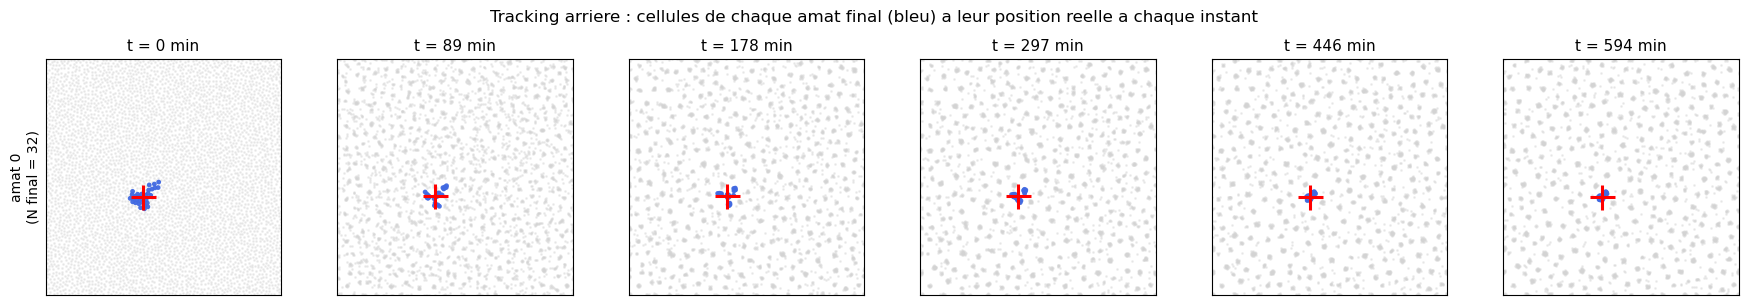


Taille du groupe et rayon de dispersion median (um) :
amat | t=   0 min        | t=  89 min        | t= 178 min        | t= 297 min        | t= 446 min        | t= 594 min        |
  0  | N=   32  r~   38um | N=   32  r~   34um | N=   32  r~   32um | N=   32  r~   19um | N=   32  r~   11um | N=   32  r~   10um |

Vitesse moyenne du centroide entre t=0 et t=594 min :
  amat 0 : centroide a parcouru     4 um en 594 min -> v=0.007 um/min


In [20]:
# --- Tracking arriere : 1 rangee par amat, 1 colonne par instant ---
# On identifie les top-K amas a t_final (clustering sur les positions FINALES),
# on garde leurs cell_id, puis a chaque instant precedent on AFFICHE LES CELLULES
# A LEUR POSITION REELLE A CET INSTANT.
# Sur la rangee k : SEUL l'amat k est en bleu vif, tout le reste en gris clair.
# La croix rouge marque le centroide du groupe (PBC).
T_FINAL = cells_df['time'].max() - 5  # instant de reference (fin du run - 5 min)
# Adapte automatiquement aux runs longs : 6 instants etales sur la duree (0 inclus)
TRACK_TIMES = sorted(set([0.0, T_FINAL * 0.15, T_FINAL * 0.30, T_FINAL * 0.50,
                          T_FINAL * 0.75, T_FINAL]))
TRACK_TOP_K    = 4    # nb d'amas suivis (= nb de rangees)
TRACK_MIN_SIZE = 30   # taille min a t_final pour etre considere "amat"

def pbc_mean(pts, L):
    """Centroide en geometrie periodique : projection sur cercle puis retour."""
    ang = pts / L * 2 * np.pi
    cx = np.arctan2(np.sin(ang[:, 0]).mean(), np.cos(ang[:, 0]).mean())
    cy = np.arctan2(np.sin(ang[:, 1]).mean(), np.cos(ang[:, 1]).mean())
    return np.array([(cx % (2*np.pi)) / (2*np.pi) * L,
                     (cy % (2*np.pi)) / (2*np.pi) * L])

# 1) Detection des amas a t_final + recuperation de leurs cell_id (= identite a suivre)
f_final = cells_df.iloc[(cells_df.time - T_FINAL).abs().argsort().iloc[:1]].frame.iloc[0]
sub_final = cells_df[cells_df.frame == f_final].reset_index(drop=True)
pts_final = sub_final[['x', 'y']].values % L
amats_final = find_amats(pts_final, L, radius=CLUSTER_RADIUS, min_size=TRACK_MIN_SIZE)[:TRACK_TOP_K]
amat_ids = [set(sub_final.iloc[idx].cell_id.values.tolist()) for idx in amats_final]
print(f"A t={T_FINAL:.0f} min : {len(amat_ids)} amas suivis (>= {TRACK_MIN_SIZE} cellules)")
for k, s in enumerate(amat_ids):
    print(f"  amat {k} : {len(s)} cellules finales")

# 2) Pre-calc : a chaque instant, on stocke les positions reelles + masque par amat
snapshots = []  # (t, pts_all, [mask_amat_0, mask_amat_1, ...])
for t_tgt in TRACK_TIMES:
    f = cells_df.iloc[(cells_df.time - t_tgt).abs().argsort().iloc[:1]].frame.iloc[0]
    sub = cells_df[cells_df.frame == f].reset_index(drop=True)
    tt = float(sub.time.iloc[0])
    pts_all = sub[['x', 'y']].values % L
    masks = [sub.cell_id.isin(ids).values for ids in amat_ids]
    snapshots.append((tt, pts_all, masks))

# 3) Figure : grille (nb amas) x (nb instants).
#    Chaque rangee k isole l'amat k en bleu vif sur fond gris clair.
nrows = len(amat_ids); ncols = len(snapshots)
fig, axes = plt.subplots(nrows, ncols, figsize=(3.0 * ncols, 3.0 * nrows), squeeze=False)
for k in range(nrows):
    for c, (tt, pts_all, masks) in enumerate(snapshots):
        ax = axes[k, c]
        ax.scatter(pts_all[:, 0], pts_all[:, 1], s=1, c='lightgrey', alpha=0.35)
        pp = pts_all[masks[k]]
        ax.scatter(pp[:, 0], pp[:, 1], s=12, c='royalblue', alpha=0.95, edgecolors='none')
        if len(pp):
            cx, cy = pbc_mean(pp, L)
            ax.plot(cx, cy, '+', color='red', markersize=18, mew=2.2)
        if c == 0:
            ax.set_ylabel(f"amat {k}\n(N final = {len(amat_ids[k])})", fontsize=10)
        if k == 0:
            ax.set_title(f"t = {tt:.0f} min", fontsize=11)
        ax.set_xlim(0, L); ax.set_ylim(0, L); ax.set_aspect('equal')
        ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Tracking arriere : cellules de chaque amat final (bleu) a leur position reelle a chaque instant",
             fontsize=12, y=1.0)
plt.tight_layout(); plt.show()

# 4) Tableau recap : taille du groupe et rayon de dispersion median (PBC) par instant
print(f"\nTaille du groupe et rayon de dispersion median (um) :")
header = "amat |" + "".join(f" t={int(tt):>4} min        |" for tt, _, _ in snapshots)
print(header)
for k in range(nrows):
    row = f"  {k}  |"
    for tt, pts_all, masks in snapshots:
        pp = pts_all[masks[k]]
        n = len(pp)
        if n:
            c = pbc_mean(pp, L)
            dxy = np.abs(pp - c); dxy = np.minimum(dxy, L - dxy)
            r = float(np.median(np.sqrt((dxy**2).sum(1))))
            row += f" N={n:>5}  r~{r:>5.0f}um |"
        else:
            row += f" N=    0  r~   nan |"
    print(row)

# 5) Vitesse moyenne du centroide (premier instant -> dernier instant suivi)
print(f"\nVitesse moyenne du centroide entre t={snapshots[0][0]:.0f} et t={snapshots[-1][0]:.0f} min :")
dt_track = snapshots[-1][0] - snapshots[0][0]
for k in range(nrows):
    pp0 = snapshots[0][1][snapshots[0][2][k]]
    pp1 = snapshots[-1][1][snapshots[-1][2][k]]
    if not len(pp0) or not len(pp1):
        print(f"  amat {k} : (un centroide manquant)"); continue
    c0, c1 = pbc_mean(pp0, L), pbc_mean(pp1, L)
    dxy = np.abs(c1 - c0); dxy = np.minimum(dxy, L - dxy)
    d = float(np.sqrt((dxy**2).sum()))
    print(f"  amat {k} : centroide a parcouru {d:5.0f} um en {dt_track:.0f} min -> v={d/dt_track:.3f} um/min")

## 9. Vitesse nette vs vitesse instantanée — la cellule avance-t-elle vraiment ?

Une cellule peut avoir une vitesse **instantanée** élevée (elle bouge à chaque pas) mais une vitesse **nette** quasi-nulle si elle fait des allers-retours. Le ratio `v_net / v_inst` est l'indicateur de **cohérence directionnelle** :

- **ratio ≈ 1** : la cellule va tout droit, déplacement efficace
- **ratio ≈ 0.5** : déplacement avec persistance modérée, marche aléatoire biaisée
- **ratio ≈ 0** : la cellule oscille sur place, déplacement instantané annulé par le retour

Si v_inst ≈ consigne mais ratio ≈ 0 → la propulsion fonctionne mais **la chimiotaxie s'inverse trop vite** (les vagues poussent dans un sens puis dans l'autre).  
Si v_inst ≪ consigne ET ratio ≈ 0 → les cellules sont **doublement bloquées** : freinées (encombrement) ET désorientées (chimiotaxie incohérente).

             fenetre | pop            |  v_inst (moy) |   v_net (moy) |   ratio v_net/v_inst
-----------------------------------------------------------------------------------------------


/var/folders/sk/m9jkmr4n1k5dqc3wj_f53p4r0000gp/T/ipykernel_2889/3143806681.py:33: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  v_inst = win[m_valid].groupby('cell_id')['v'].mean()


  [    0,    50]    | Population 1   |        0.6648 |        0.1533 |                0.231
  [    0,    50]    | Population 2   |        0.4881 |        0.1163 |                0.238



/var/folders/sk/m9jkmr4n1k5dqc3wj_f53p4r0000gp/T/ipykernel_2889/3143806681.py:33: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  v_inst = win[m_valid].groupby('cell_id')['v'].mean()


  [   50,   150]    | Population 1   |        0.4596 |        0.1299 |                0.283
  [   50,   150]    | Population 2   |        0.3495 |        0.1183 |                0.339



...

  [  150,   300]    | Population 1   |        0.2914 |        0.0471 |                0.161
  [  150,   300]    | Population 2   |        0.2112 |        0.0447 |                0.212



/var/folders/sk/m9jkmr4n1k5dqc3wj_f53p4r0000gp/T/ipykernel_2889/3143806681.py:33: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  v_inst = win[m_valid].groupby('cell_id')['v'].mean()


  [  300,   500]    | Population 1   |        0.2602 |        0.0299 |                0.115
  [  300,   500]    | Population 2   |        0.1862 |        0.0266 |                0.143



/var/folders/sk/m9jkmr4n1k5dqc3wj_f53p4r0000gp/T/ipykernel_2889/3143806681.py:33: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  v_inst = win[m_valid].groupby('cell_id')['v'].mean()


  [  500,   600]    | Population 1   |        0.2460 |        0.0302 |                0.123
  [  500,   600]    | Population 2   |        0.1770 |        0.0262 |                0.148

  [    0,   600]    | Population 1   |        0.3324 |        0.0386 |                0.116
  [    0,   600]    | Population 2   |        0.2432 |        0.0341 |                0.140



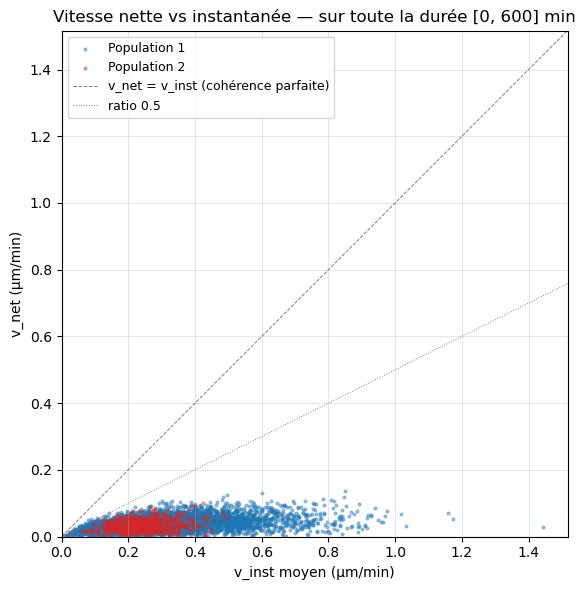


Ratio v_net/v_inst global (toute la simu): 0.119
  -> proche de 1 : cellules vont (presque) tout droit
  -> proche de 0 : oscillations sur place, deplacement net nul


In [21]:
# --- Vitesse nette vs instantanee par cellule, sur plusieurs fenetres temporelles ---
# v_inst : moyenne de la vitesse instantanee deja calculee dans la § 6 (cells_df['v'])
# v_net  : norme(position_finale - position_initiale) / duree, avec correction PBC

def displacement_pbc(p_start, p_end, L):
    """Deplacement avec correction de bord periodique (chaque composante)."""
    d = p_end - p_start
    d = (d + L/2) % L - L/2
    return d

# Fenetres adaptees aux runs longs (auto-extension)
T_MAX = cells_df['time'].max()
WINDOWS = [(0, min(50, T_MAX)), (50, 150), (150, 300), (300, 500),
           (500, T_MAX), (0, T_MAX)]
WINDOWS = [w for w in WINDOWS if w[0] < T_MAX and w[1] - w[0] > 5]

print(f"{'fenetre':>20s} | {'pop':14s} | {'v_inst (moy)':>13s} | {'v_net (moy)':>13s} | {'ratio v_net/v_inst':>20s}")
print("-" * 95)

m_valid = cells_df.dt.notna() & (cells_df.dt > 0)

for t0, t1 in WINDOWS:
    win = cells_df[(cells_df.time >= t0) & (cells_df.time <= t1)]
    if win.empty: continue
    ws = win.sort_values('time')
    p_start = ws.groupby('cell_id').first()[['x', 'y', 'pop_tag']]
    p_end   = ws.groupby('cell_id').last()[['x', 'y', 'time']]
    t_start = ws.groupby('cell_id').first()['time']
    dt_cell = p_end['time'] - t_start
    d_net = displacement_pbc(p_start[['x','y']].values, p_end[['x','y']].values, L)
    dist_net = np.sqrt((d_net**2).sum(axis=1))
    v_net = dist_net / dt_cell.values
    v_inst = win[m_valid].groupby('cell_id')['v'].mean()
    pop = p_start['pop_tag']
    df_w = pd.DataFrame({'v_net': v_net, 'v_inst': v_inst, 'pop': pop}).dropna()
    for popname, g in df_w.groupby('pop', observed=True):
        if len(g) < 5: continue
        m_v_inst = g['v_inst'].mean()
        m_v_net  = g['v_net'].mean()
        ratio = m_v_net / m_v_inst if m_v_inst > 1e-12 else 0.0
        print(f"  [{t0:5.0f}, {t1:5.0f}]    | {popname:14s} | {m_v_inst:13.4f} | {m_v_net:13.4f} | {ratio:>20.3f}")
    print()

# Plot par cellule : v_net vs v_inst sur toute la simu
fig, ax = plt.subplots(figsize=(8, 6))
t0, t1 = 0, T_MAX
win = cells_df[(cells_df.time >= t0) & (cells_df.time <= t1)]
ws = win.sort_values('time')
p_start = ws.groupby('cell_id').first()[['x', 'y', 'pop_tag']]
p_end   = ws.groupby('cell_id').last()[['x', 'y', 'time']]
t_start = ws.groupby('cell_id').first()['time']
dt_cell = p_end['time'] - t_start
d_net = displacement_pbc(p_start[['x','y']].values, p_end[['x','y']].values, L)
v_net = np.sqrt((d_net**2).sum(axis=1)) / dt_cell.values
v_inst = win[m_valid].groupby('cell_id')['v'].mean()
df_scatter = pd.DataFrame({'v_net': v_net, 'v_inst': v_inst,
                           'pop': p_start['pop_tag']}).dropna()
colors_map = {"Population 1": "tab:blue", "Population 2": "tab:red"}
for popname, g in df_scatter.groupby('pop', observed=True):
    ax.scatter(g['v_inst'], g['v_net'], s=4, alpha=0.4,
               c=colors_map.get(popname, 'gray'), label=popname)
vmax = max(df_scatter['v_inst'].max(), df_scatter['v_net'].max()) * 1.05
ax.plot([0, vmax], [0, vmax], 'k--', lw=0.7, alpha=0.5, label='v_net = v_inst (cohérence parfaite)')
ax.plot([0, vmax], [0, vmax/2], 'gray', ls=':', lw=0.7, label='ratio 0.5')
ax.set_xlabel('v_inst moyen (µm/min)'); ax.set_ylabel('v_net (µm/min)')
ax.set_title(f'Vitesse nette vs instantanée — sur toute la durée [{t0:.0f}, {t1:.0f}] min')
ax.legend(loc='upper left', fontsize=9); ax.set_aspect('equal'); ax.grid(alpha=0.3)
ax.set_xlim(0, vmax); ax.set_ylim(0, vmax)
plt.tight_layout(); plt.show()

print(f"\nRatio v_net/v_inst global (toute la simu): "
      f"{df_scatter['v_net'].mean() / df_scatter['v_inst'].mean():.3f}")
print("  -> proche de 1 : cellules vont (presque) tout droit")
print("  -> proche de 0 : oscillations sur place, deplacement net nul")

## 10. Cellules sur champ cAMP — vue d'ensemble spatiale

À chaque instant on superpose :
- le **champ cAMP** en niveaux de gris (échelle log, fond)
- toutes les **cellules** en rouge
- les **pionnières** en croix bleues

Cette vue révèle des **motifs structurés** qu'aucune métrique scalaire ne capture : grille régulière d'agrégats (motif de Turing), streams, mounds isolés, ou simple bruit.

Lecture :
- **points rouges éparpillés uniformément** + cAMP uniforme → pas d'organisation
- **points rouges en grille régulière** → cristallisation d'oscillateurs (chaque amat est sa propre source, repousse ses voisins)
- **un gros paquet rouge dense** + cAMP fort autour → vrai mound qui s'est formé
- **filaments rouges entre les paquets** → streaming en cours

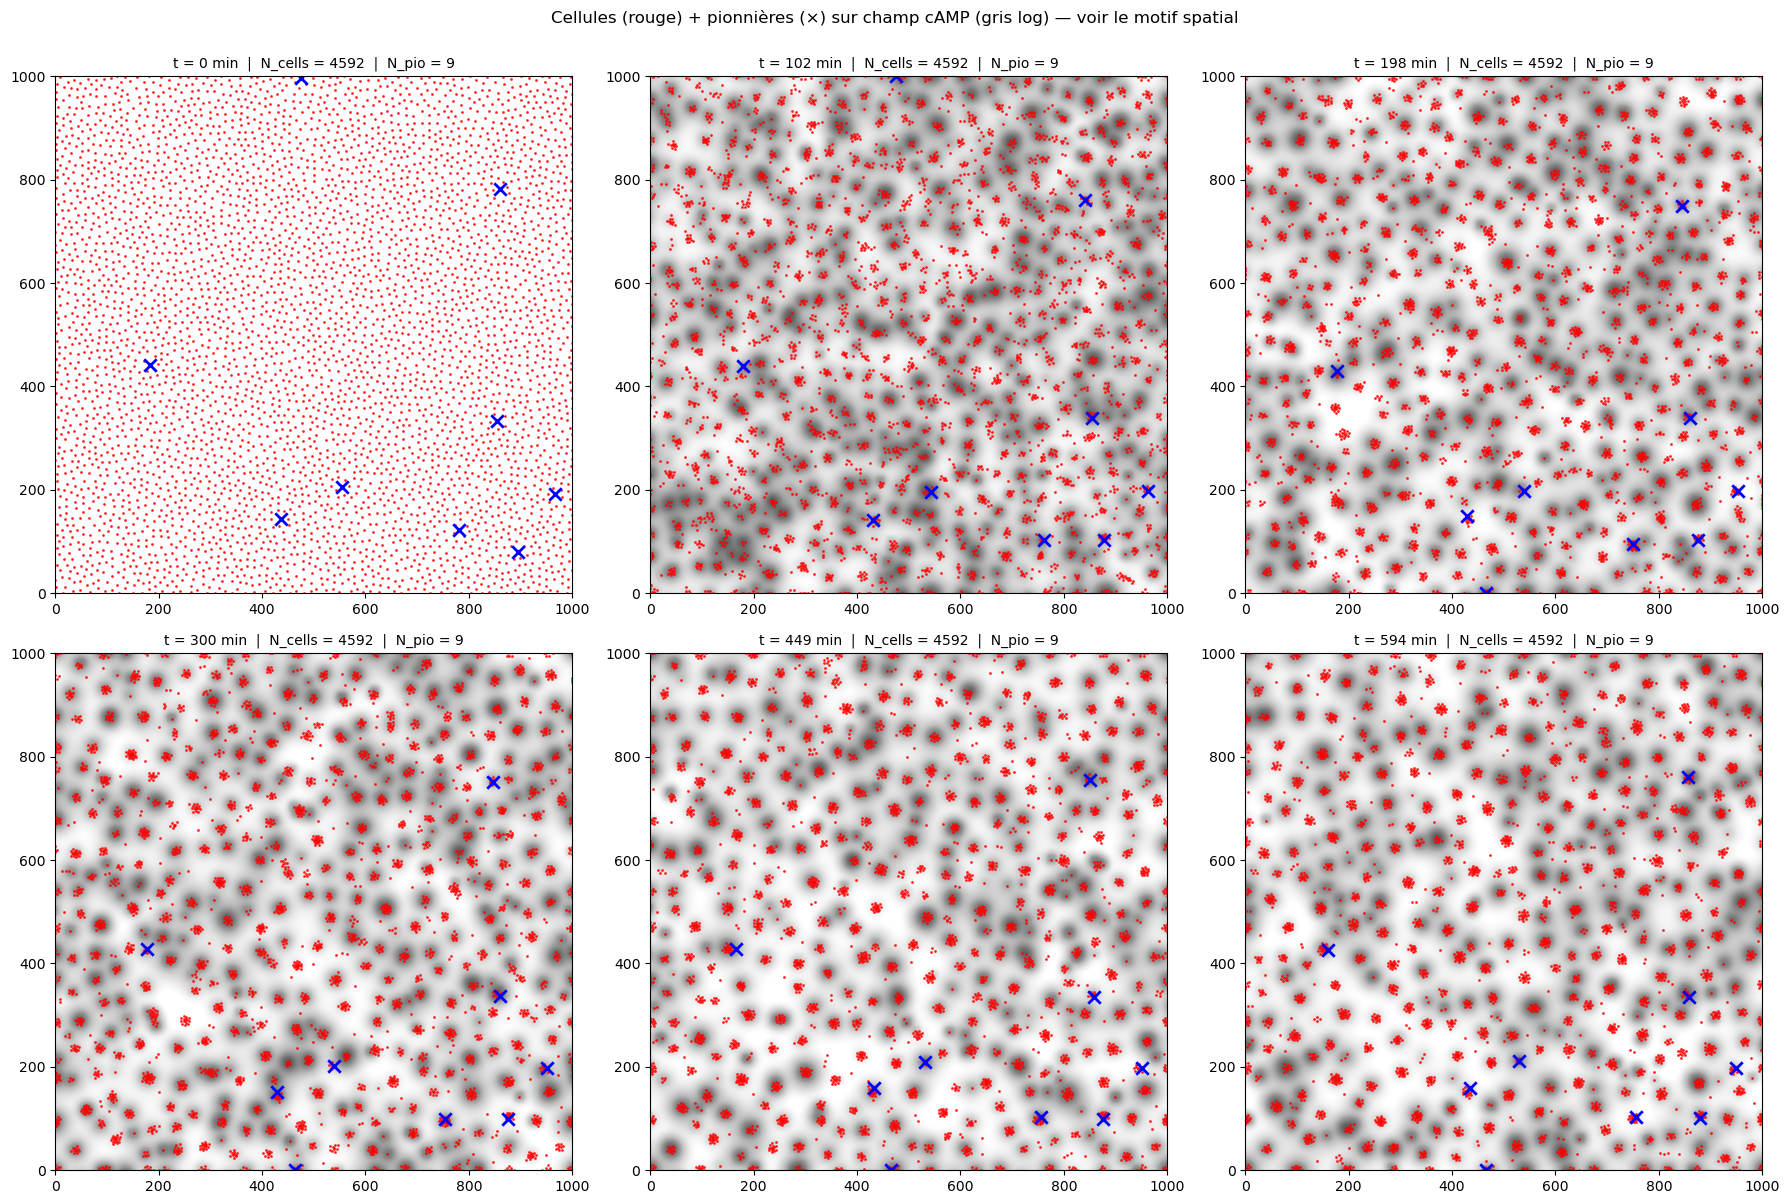

In [22]:
# --- Snapshots 2D : cellules sur champ cAMP, 6 instants ---
from matplotlib.colors import LogNorm as _LogNorm

# 6 instants etales, t=0 inclus
T_MAX_LOC = cells_df['time'].max()
SNAP_TIMES = [0, T_MAX_LOC*0.17, T_MAX_LOC*0.33, T_MAX_LOC*0.5, T_MAX_LOC*0.75, T_MAX_LOC - 5]

# Index frames champs par temps (pour aller chercher le .npy le plus proche)
def _camp_at(t_tgt):
    """Charge le champ cAMP a l'instant le plus proche de t_tgt."""
    files = sorted(glob.glob(os.path.join(fields_dir, "camp_*.npy")),
                   key=lambda f: int(re.search(r"camp_(\d+)", f).group(1)))
    its = [int(re.search(r"camp_(\d+)", f).group(1)) for f in files]
    it2t_local = {}
    if os.path.exists(ftimes_path):
        ft = pd.read_csv(ftimes_path); it2t_local = dict(zip(ft.iteration, ft.time))
    times_npy = [it2t_local.get(i, i*0.001) for i in its]
    k = int(np.argmin([abs(tt - t_tgt) for tt in times_npy]))
    return np.load(files[k]), float(times_npy[k])

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
for ax, t_tgt in zip(axes.flat, SNAP_TIMES):
    g, t_npy = _camp_at(t_tgt)
    ax.imshow(g.T * 1e9, origin='lower', extent=[0, L, 0, L],
              cmap='Greys', norm=_LogNorm(vmin=0.5, vmax=300))
    # cellules a l'instant le plus proche
    f = cells_df.iloc[(cells_df.time - t_tgt).abs().argsort().iloc[:1]].frame.iloc[0]
    sub = cells_df[cells_df.frame == f]
    ax.scatter(sub.x, sub.y, s=1.2, c='red', alpha=0.7)
    pio = sub[sub.is_pioneer]
    ax.scatter(pio.x, pio.y, s=80, c='blue', marker='x', linewidths=2)
    ax.set_title(f't = {t_npy:.0f} min  |  N_cells = {len(sub)}  |  N_pio = {len(pio)}',
                 fontsize=10)
    ax.set_xlim(0, L); ax.set_ylim(0, L); ax.set_aspect('equal')
fig.suptitle("Cellules (rouge) + pionnières (×) sur champ cAMP (gris log) — voir le motif spatial", y=1.0)
plt.tight_layout(); plt.show()